# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

In [1]:
!pip install shap

In [2]:
df.columns

NameError: name 'df' is not defined

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-09 14:12:47,682] A new study created in memory with name: no-name-bf4f8084-eecb-49df-b0df-31ecb0b9a036


[I 2026-04-09 14:12:47,826] Trial 0 finished with value: 0.7058823529411765 and parameters: {'n_estimators': 138, 'max_depth': 6}. Best is trial 0 with value: 0.7058823529411765.
[I 2026-04-09 14:12:48,015] Trial 1 finished with value: 0.7538461538461538 and parameters: {'n_estimators': 178, 'max_depth': 13}. Best is trial 1 with value: 0.7538461538461538.
[I 2026-04-09 14:12:48,188] Trial 2 finished with value: 0.6896551724137931 and parameters: {'n_estimators': 188, 'max_depth': 4}. Best is trial 1 with value: 0.7538461538461538.
[I 2026-04-09 14:12:48,410] Trial 3 finished with value: 0.7301587301587301 and parameters: {'n_estimators': 212, 'max_depth': 9}. Best is trial 1 with value: 0.7538461538461538.
[I 2026-04-09 14:12:48,676] Trial 4 finished with value: 0.7424242424242424 and parameters: {'n_estimators': 249, 'max_depth': 13}. Best is trial 1 with value: 0.7538461538461538.
[I 2026-04-09 14:12:48,959] Trial 5 finished with value: 0.711864406779661 and parameters: {'n_estimato

RF F1: 0.71875
LR F1: 0.71875
SVM F1: 0.7244094488188977
KNN F1: 0.7555555555555555


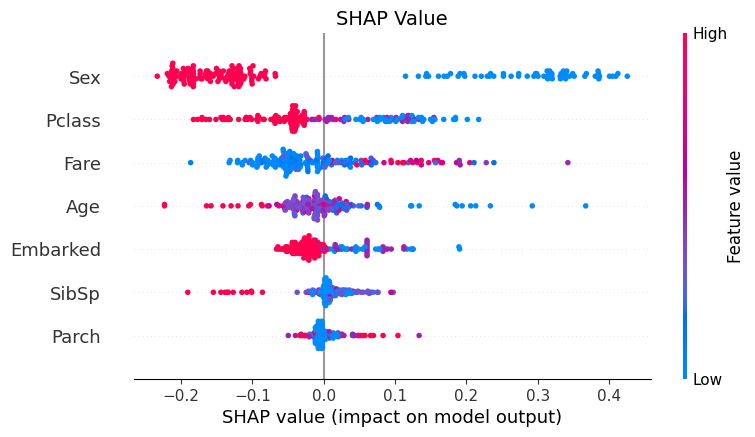

Stacking F1: 0.75


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [ ]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])


# split
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['churn'])

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0600
lightgbm,Light Gradient Boosting Machine,0.8559,0.8499,0.4768,0.7237,0.5726,0.4907,0.5073,0.1300
gbc,Gradient Boosting Classifier,0.8614,0.8638,0.4549,0.7735,0.5708,0.4951,0.5209,0.1420
catboost,CatBoost Classifier,0.8584,0.8641,0.4637,0.7472,0.5708,0.4918,0.5126,1.0830
rf,Random Forest Classifier,0.8582,0.8443,0.4436,0.7601,0.5593,0.4820,0.5072,0.1600
xgboost,Extreme Gradient Boosting,0.8441,0.8396,0.4786,0.6645,0.5555,0.4641,0.4738,0.0420
et,Extra Trees Classifier,0.8532,0.8424,0.4269,0.7459,0.5418,0.4622,0.4883,0.1200
dt,Decision Tree Classifier,0.7862,0.6777,0.4943,0.4769,0.4849,0.3502,0.3507,0.0120
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0130
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0110


In [ ]:
df

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,0.00,2,1,0,96270.64,0
9996,516,0,1,35,10,57369.61,1,1,1,101699.77,0
9997,709,0,0,36,7,0.00,1,0,1,42085.58,1
9998,772,1,1,42,3,75075.31,2,1,0,92888.52,1


In [2]:
# 데이터 로드
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)


# 결측치 확인
print(df.isnull().sum())

# 'customer_id' 열 삭제 
df = df.drop('customer_id', axis=1)

# 삭제 후 상위 5개 행 확인
print(df.head())

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64
   credit_score country  gender  age  tenure    balance  products_number  \
0           619  France  Female   42       2       0.00                1   
1           608   Spain  Female   41       1   83807.86                1   
2           502  France  Female   42       8  159660.80                3   
3           699  France  Female   39       1       0.00                2   
4           850   Spain  Female   43       2  125510.82                1   

   credit_card  active_member  estimated_salary  churn  
0            1              1         101348.88      1  
1            0              1         112542.58      0  
2            1              0         113931.57      1  
3            0              0         

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   country           10000 non-null  object 
 2   gender            10000 non-null  object 
 3   age               10000 non-null  int64  
 4   tenure            10000 non-null  int64  
 5   balance           10000 non-null  float64
 6   products_number   10000 non-null  int64  
 7   credit_card       10000 non-null  int64  
 8   active_member     10000 non-null  int64  
 9   estimated_salary  10000 non-null  float64
 10  churn             10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


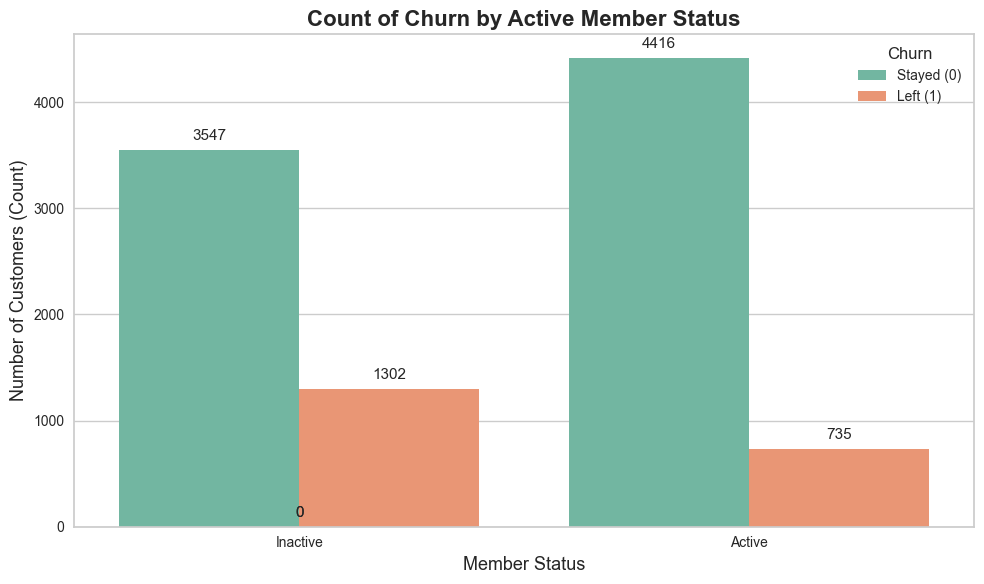

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# hue에 churn 여부를 넣고 x 축에는 active_member로 설정했습니다

ax = sns.countplot(x='active_member', hue='churn', data=df, palette='Set2')

        # 한글 계속 오류나서, 영어로 변형했습니다
plt.title('Count of Churn by Active Member Status', fontsize=16, fontweight='bold')
plt.xlabel('Member Status', fontsize=13)
plt.ylabel('Number of Customers (Count)', fontsize=13)

plt.xticks([0, 1], ['Inactive', 'Active'])

plt.legend(title='Churn', labels=['Stayed (0)', 'Left (1)'])


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# 우선 df.info 를 통해서, churn에 있어서 어떤 점들 비교해봐야 괜찮을까 했을 때, 
# Active_member 유뮤에 따라 어떤분포를 보이고 있을까에 대해서, 분석을 해봤습니다. 
# 잔액이 0인 고객과 0이 아닌 고객으로 두 분류로 나눠서 잔액애 따라 inactive와 active로 분류를 였습니다
# 그 결과 잔액의 유무와 상관 없이 고객 이탈에 있어서는 유지 측면이 더 많은 것으로 보입니다.

Text(0.5, 1.0, 'Distribution of Churned Customers by Country')

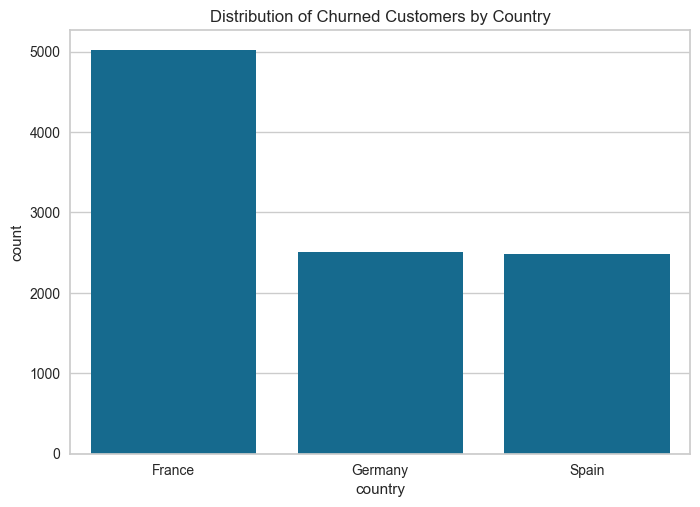

In [5]:
left_only = df[df['churn'] == 1]
sns.countplot(x='country', data=df, order=df['country'].value_counts().index)
plt.title('Distribution of Churned Customers by Country')

In [ ]:
# 그럼 churn == 1 인 고객을 대상으로 어느 country에서 많은 이탈을 보였나에 대해서 분석해본 결과 France가 압도적으로 컸습니다
# 하지만 France 고객 자체가 많아서 다음과 같은 현상이 발생 할 수도 있습니다.
# 이에 따라 이탈률(%) 로 계산해봤습니다

In [6]:
# 국가별 이탈률 계산
country_churn_rate = df.groupby('country')['churn'].mean().sort_values(ascending=False)
print(country_churn_rate)

country
Germany    0.324432
Spain      0.166734
France     0.161548
Name: churn, dtype: float64


In [7]:
# 이탈률로 보면 아무래도, 프랑스가 상대적으로 고객 수는 많았지만, 비율로 봤을 때는, Germany가 많은 비율로 이탈합니다
# 이에 따라 독일의 큰 고객들이 떠다는지 확인해보고 싶었습니다

Text(0.5, 1.0, 'Germany: Balance Distribution by Churn')

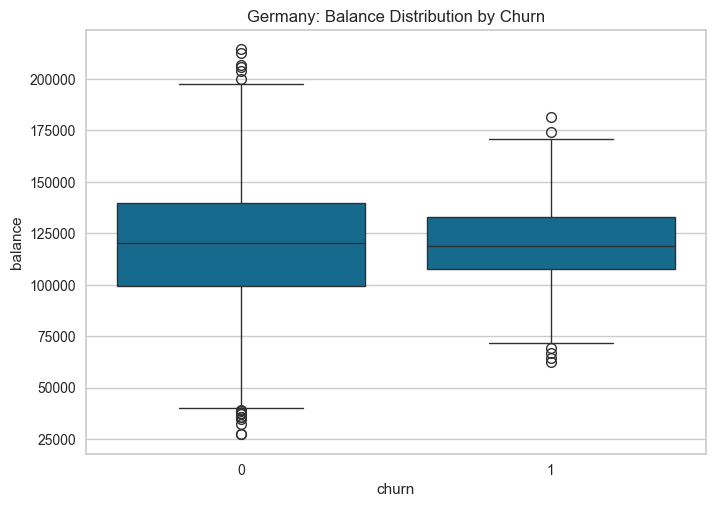

In [8]:
germany_df = df[df['country'] == 'Germany']
sns.boxplot(x='churn', y='balance', data=germany_df)
plt.title('Germany: Balance Distribution by Churn')

In [ ]:
# 기대했던 것과 달리, 이탈 여부에 따른 독일 국적의 고객의 차이가 금액 차이는 아니었습니다
# 이에 따라 다른 시각으로 봐야할 필요가 있어보입니다

In [ ]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn', 'is_zero_balance'],
      dtype='object')

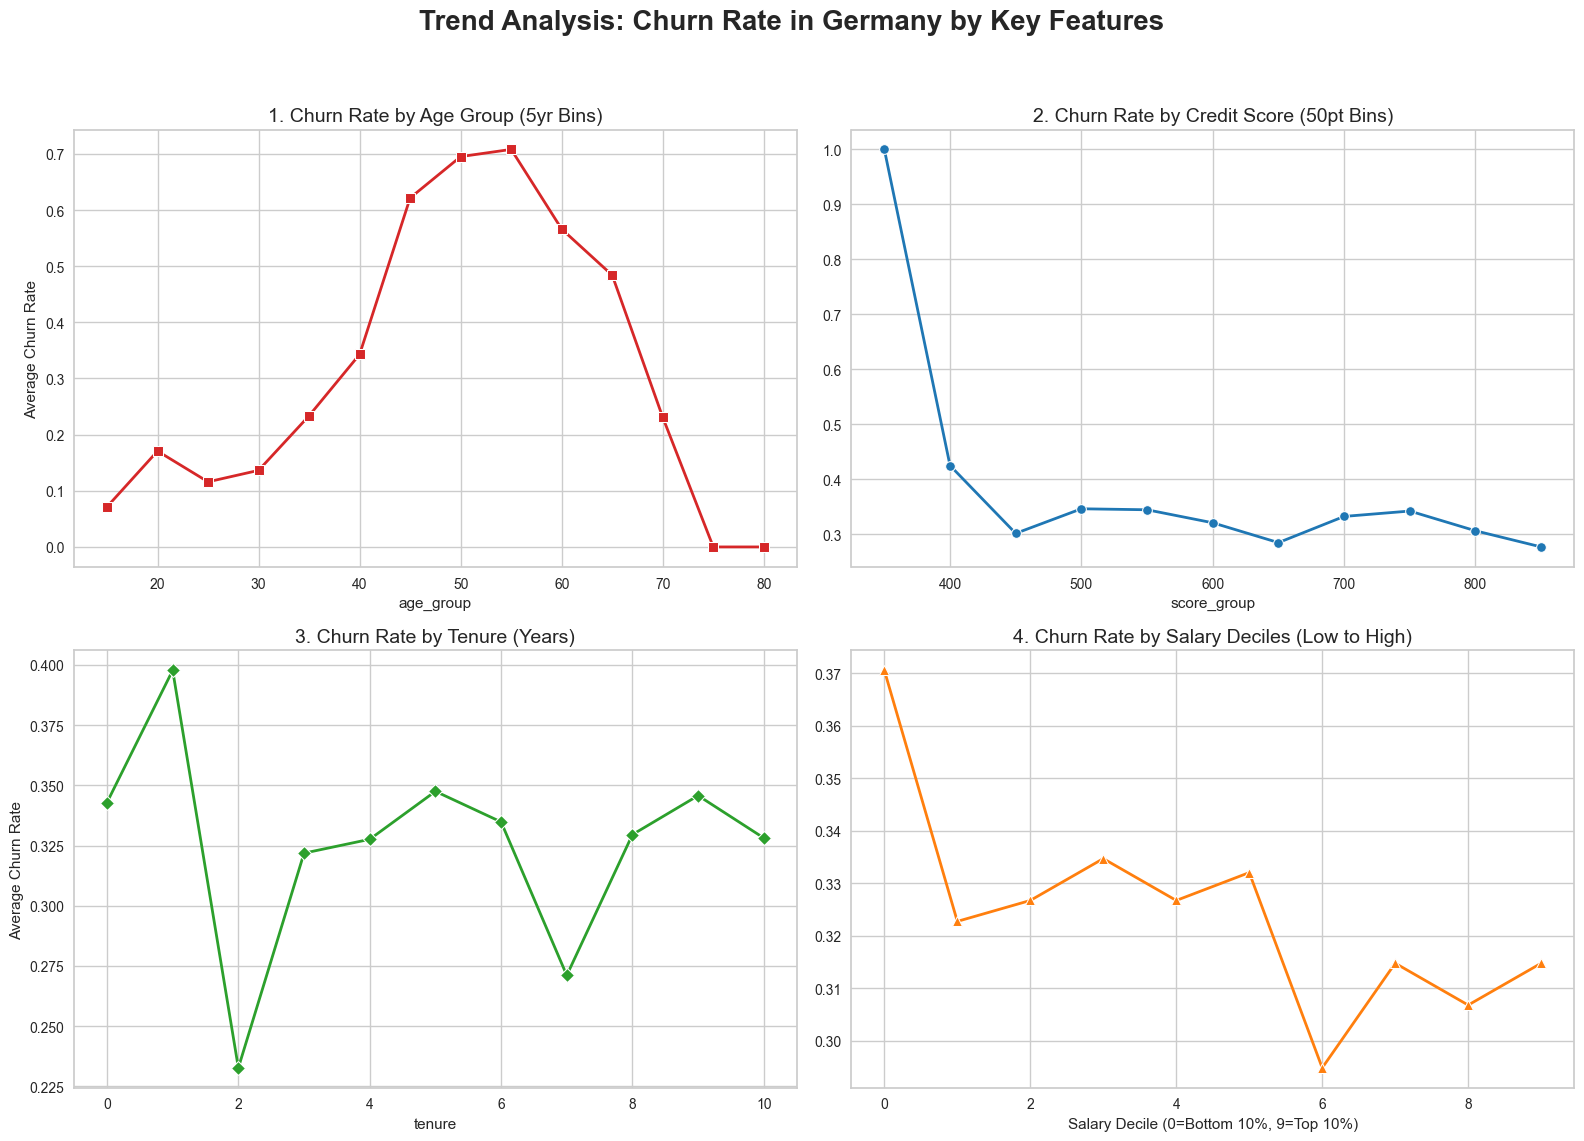

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Germany만 가져옵니다
germany_df = df[df['country'] == 'Germany'].copy()

# 2. fig, axes 2,2 로 설정해서 4ㅐ개의 공간으로 만들었습니다
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Trend Analysis: Churn Rate in Germany by Key Features', fontsize=20, fontweight='bold')

# --- Plot 1: 나이 vs 이탈률 ---
# 5년 단위를 기준으로 하여 나이 별 이탈률 계산하는 식
germany_df['age_group'] = (germany_df['age'] // 5) * 5
age_trend = germany_df.groupby('age_group')['churn'].mean()
sns.lineplot(ax=axes[0, 0], x=age_trend.index, y=age_trend.values, marker='s', color='#d62728', linewidth=2)
axes[0, 0].set_title('1. Churn Rate by Age Group (5yr Bins)', fontsize=14)
axes[0, 0].set_ylabel('Average Churn Rate')

# --- Plot 2: 신용점수 vs 이탈률 ---
# 50 포인트 당 이탈률에 대한 분석
germany_df['score_group'] = (germany_df['credit_score'] // 50) * 50
score_trend = germany_df.groupby('score_group')['churn'].mean()
sns.lineplot(ax=axes[0, 1], x=score_trend.index, y=score_trend.values, marker='o', color='#1f77b4', linewidth=2)
axes[0, 1].set_title('2. Churn Rate by Credit Score (50pt Bins)', fontsize=14)

# --- Plot 3: 고객 기간 vs 이탈률 ---
# 고객 년수에 따른 이탈률
tenure_trend = germany_df.groupby('tenure')['churn'].mean()
sns.lineplot(ax=axes[1, 0], x=tenure_trend.index, y=tenure_trend.values, marker='D', color='#2ca02c', linewidth=2)
axes[1, 0].set_title('3. Churn Rate by Tenure (Years)', fontsize=14)
axes[1, 0].set_ylabel('Average Churn Rate')

# --- Plot 4: 봉급 vs 이탈률  ---
# 10% 씩 단위로 나눠서 상 하위를 구분 하여보았습니다.
germany_df['salary_bin'] = pd.qcut(germany_df['estimated_salary'], 10, labels=False)
salary_trend = germany_df.groupby('salary_bin')['churn'].mean()
sns.lineplot(ax=axes[1, 1], x=salary_trend.index, y=salary_trend.values, marker='^', color='#ff7f0e', linewidth=2)
axes[1, 1].set_title('4. Churn Rate by Salary Deciles (Low to High)', fontsize=14)
axes[1, 1].set_xlabel('Salary Decile (0=Bottom 10%, 9=Top 10%)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# 위 과정 동안, 다음과 같이 분석했습니다
# 잔고 balance가 0과 0이 아닌 두 집단으로 분류를 하고 그에 따라 고객 이탈률이 어떻게 구성되어 있는지에 따라 비교를 해본 결과,
# 생각보다 큰 차이가 없었습니다.
# 그 뒤에 churn이 1인 집단을 대상으로, 어떤 국가에서 가장 큰 이탈률을 보이는지에 대해서 알아본 뒤, 그 국가는 독일인 것을 알게됐습니다.
# Germany를 타겟팅 하여 그 국가의 고객들의 현상태를 파악하고, 그에 맞는 대비를 및 보완을 해볼 수 있도록, 원인에 대해 분석해봤습니다

# (바로 위 그래프)
# 1. 나이대 별 이탈률 (5년 단위)

# 2,30대에서는 낮은 평균 이탈률을 보여주다가 40 -> 50 부근에서 가장 높은 상승률을 보이다가 서서히 내려옵니다.
# 그렇다면 5,60 대의 나이대에서는 보통, 은퇴를 준비하는 시기인점을 고려해서, 퇴직상품으로 이어질 수 있는 상품을 제시하는게
# 고객 유지에서 좋은 효과를 보이지 않을까 라는 생각입니다

# 2. 신용점수 별 이탈률 (50점 단위)
# 그렇다면, 신용점수에 따른 고객 이탈률에 대해서 알아본 결과, 400점대 이하를 제외하고는 비슷한 평균 이탈률을 보입니다.
# 아무래도, 신용점수에 대한 표본이 부족할 뿐 더러, 신용 점수로 인해, 거래를 계속 유지하는 것도 힘든 현실적 요소도 있어보임에 따라, 별 영향이 없어보인다는 해석입니다.

# 3. 이용 기간에 따른 이탈률 (연 단위)
# 가입 기간별 고객에 대해서 분석해본 결과 1년차에 가장 많은 고객들이 이탈을 합니다
# 쓸 메리트가 없어서 떠나는게 아닐까 라는 분석입니다.
# 장기 고객으로 만드려면 은퇴후에도 이용할 수 있는 다양한 패키지가 필요로 해보입니다
# 주 고객으로 만들만한 상징성이 필요해보입니다

# 4. 샐러리 별 이탈률 (X =1 당, 소득 10%)
# 소득 percetage에 따라 이탈률에 대해서 분석해봤습니다 하위 10%와 상위 10%를 비교했을 때에는 명백한 차이를 보이고 있습니다
# 소득이 가장 적은 고객에서 높은 이탈률을 보이고 있지만, 이것은 사실 salary를 고려 했을 때, 젊은 층이 많을 것으로 보인다는 제 해석입니다
# 실제로, 청년 가입률을 높이기 위해서는 한국같은 경우, 도약계좌 같은 파격적인 고금리 상품을 내세우며 가입을 유도하고 있습니다.
# 파격적 상품을 통해 다양한 연령층의 고객들을 포섭할 필요가 있어보입니다

# 결론
# 5,60대의 고령 이탈 고객들을 위한 상품, 젊은 고객층(추정)을 위한 신규고객 유치 상품이 필요로 해보인다

In [ ]:
import pandas as pd
import shap
import matplotlib.pyplot as plt

from pycaret.classification import *


# 데이터 불러오기

df = pd.read_csv("C:\\Users\\campus4D023\\Downloads\\Bank Customer Churn Prediction.csv")
# 인식이 안돼서 경로를 바꿔봤습니다

# customer_id 제거..
if 'customer_id' in df.columns:
    df = df.drop('customer_id', axis=1)

print("데이터 shape:", df.shape)
print(df.head())


# PyCaret setup
exp = setup(
    data=df,
    target='churn',
    session_id=42,
    fix_imbalance=False,   # 속도 위해 False
    fold=3,                # 속도 위해 3-fold
    verbose=False
)


# F1 Score 기준 상위 4개 모델 비교

print("\nF1 Score 기준 상위 4개 모델 찾는 중...")
top4_models = compare_models(
    n_select=4,
    sort='F1'
)

print("\n선정된 top4 모델:")
for i, model in enumerate(top4_models):
    print(f"{i+1}번째 모델:", model)

# top4 모델 Optuna로 각각 5번 튜닝

tuned_top4_models = []

print("\n상위 4개 모델 튜닝 시작...\n")

for i, model in enumerate(top4_models):
    print(f"{i+1}번째 모델 튜닝 중: {model}")
    
    # optuna에서 찾고, 최적화 방식은 f1 score로 합니다, 횟수는 최대한 빠르게 하기 위해서 5회로 했습니다, fold수도 역시 3회로했습니다
    tuned_model = tune_model(
        model,
        search_library='optuna',
        optimize='F1',
        n_iter=5,              # 5번만 탐색
        choose_better=True,
        fold=3,
        verbose=False
    )
    
    tuned_top4_models.append(tuned_model)

# 튜닝 된 모델 순서를 알려줍니다
for i, model in enumerate(tuned_top4_models):
    print(f"{i+1}번째 튜닝 모델:", model)




# Random Forest 모델 찾기

# 우선 공백으로 만들어 주고 채워줍니다
rf_model = None

# top4 에 선정된 모델에서 RFC를 찾아줍니다
for model in tuned_top4_models:
    if "RandomForestClassifier" in str(type(model)):
        rf_model = model
        break
# if 구문으로 RFC 유무 찾기
if rf_model is None:
    print("\n top4 안에 RandomForestClassifier가 없습니다.")
    print("→ SHAP은 Tree 기반 모델 중 하나로 대체 가능")
else:
    print("\n선택된 RF 모델:")
    print(rf_model)


# RF 모델 성능 확인

if rf_model is not None:
    print("\nRF 모델 성능 평가:")
    predict_model(rf_model)
    rf_result = pull()
    print(rf_result)


데이터 shape: (10000, 11)
   credit_score country  gender  age  tenure    balance  products_number  \
0           619  France  Female   42       2       0.00                1   
1           608   Spain  Female   41       1   83807.86                1   
2           502  France  Female   42       8  159660.80                3   
3           699  France  Female   39       1       0.00                2   
4           850   Spain  Female   43       2  125510.82                1   

   credit_card  active_member  estimated_salary  churn  
0            1              1         101348.88      1  
1            0              1         112542.58      0  
2            1              0         113931.57      1  
3            0              0          93826.63      0  
4            1              1          79084.10      0  

F1 Score 기준 상위 4개 모델 찾는 중...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8550,0.8483,0.4811,0.7145,0.5746,0.4912,0.5054,0.2067
catboost,CatBoost Classifier,0.8577,0.8568,0.4685,0.7373,0.5726,0.4923,0.5108,1.5100
gbc,Gradient Boosting Classifier,0.8607,0.8578,0.4551,0.7671,0.5705,0.4939,0.5183,0.2500
rf,Random Forest Classifier,0.8580,0.8447,0.4467,0.7566,0.5615,0.4834,0.5075,0.2100
xgboost,Extreme Gradient Boosting,0.8424,0.8302,0.4685,0.6595,0.5475,0.4555,0.4654,0.0767
ada,Ada Boost Classifier,0.8496,0.8332,0.4425,0.7105,0.5450,0.4607,0.4794,0.1000
et,Extra Trees Classifier,0.8470,0.8348,0.4089,0.7206,0.5207,0.4379,0.4633,0.1933
dt,Decision Tree Classifier,0.7791,0.6745,0.4979,0.4609,0.4784,0.3387,0.3392,1.0667
lda,Linear Discriminant Analysis,0.8070,0.7567,0.2139,0.5718,0.3110,0.2249,0.2621,0.0433
lr,Logistic Regression,0.8113,0.7494,0.1956,0.6179,0.2968,0.2203,0.2696,1.8600



선정된 top4 모델:
1번째 모델: LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)
2번째 모델: CatBoostClassifier(border_count=254, random_state=42, task_type='CPU', verbose=False)
3번째 모델: GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_cha

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Random Forest Classifier,0.8470,0.8778,0.6825,0.6114,0.6450,0.5479,0.5492


                      Model  Accuracy     AUC  Recall   Prec.     F1   Kappa  \
0  Random Forest Classifier     0.847  0.8778  0.6825  0.6114  0.645  0.5479   

      MCC  
0  0.5492  


X_test_sample shape: (200, 12)
shap_values shape: (200, 12, 2)


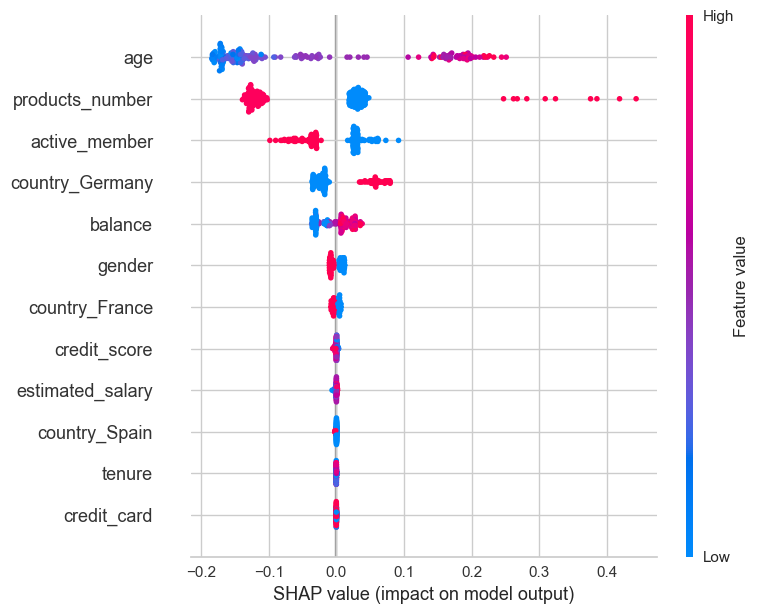


상위 4개 모델 Stacking 시작...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8569,0.8458,0.4412,0.7554,0.5570,0.4786,0.5033
1,0.8641,0.8588,0.5179,0.7365,0.6082,0.5290,0.5410
2,0.8607,0.8642,0.4589,0.7622,0.5729,0.4958,0.5186
Mean,0.8606,0.8563,0.4727,0.7514,0.5794,0.5011,0.5209
Std,0.0030,0.0077,0.0328,0.0109,0.0214,0.0209,0.0155



Stacking 모델 성능 평가 중...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Stacking Classifier,0.8700,0.8811,0.5139,0.7715,0.6169,0.5424,0.5586



Stacking 모델 성능 결과:
                 Model  Accuracy     AUC  Recall   Prec.      F1   Kappa  \
0  Stacking Classifier      0.87  0.8811  0.5139  0.7715  0.6169  0.5424   

      MCC  
0  0.5586  


In [ ]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)

# rf_model이 없는상태라면

if rf_model is not None:
    
# X_test_sample에 일부만 뽑습니다 transformed에서 200개 만큼
    X_test_sample = X_test_transformed.sample(
        min(200, len(X_test_transformed)),
        random_state=42
    )
# 랜덤포레스트 모델이 이 데이터를 보고 어떤 변수 때문에 예측했는지 확인합니다
# SHAP 분석기 (gpt를 참고해서 만든 함수입니다 ..)
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test_sample)

    print("X_test_sample shape:", X_test_sample.shape)

    # shap_values 형태 확인

    # shap values가 list인지 확인
    if isinstance(shap_values, list):
        print("shap_values is list")
        print("각 클래스 shap shape:", [sv.shape for sv in shap_values])
        shap_to_plot = shap_values[1]   # churn=1 클래스
    else:
        print("shap_values shape:", shap_values.shape)

        # SHAP 결과가 3차원이면 chrun =1 클래스만 꺼냅니다
        if len(shap_values.shape) == 3:
            shap_to_plot = shap_values[:, :, 1]   
        else:
            shap_to_plot = shap_values

    shap.summary_plot(shap_to_plot, X_test_sample)


# 4개 모델을 Stacking (전방모델, 후방모델 아무거나) F1_score, accuracy score (80,57)


# 상위 4개 모델 Stacking


stacked_model = stack_models(
    estimator_list=tuned_top4_models,
    optimize='F1',
    fold=3,
    choose_better=True
)


# Stacking 모델 성능 확인

predict_model(stacked_model)
stack_result = pull()

# 모델 성능 결과ㅣ
print(stack_result)


In [ ]:
# SHAP 분석 결과 age는 고객 이탈 예측에서 가장 중요한 변수로 나타났습니다
# 나이가 높을 수록 SHAP value 가 양으로 형성 되어있습니다. 반면 어린 고객들은 이탈가능성이 상대적으로 낮은것을 알 수 있습니다
# products_number 에서는, 상품수에 따라 분류가 돼있는데, 비선형적인 패턴을 보이고 있습니다
# 상품이 적을수록 이탈과 관련이 있지만, 소수에 있어서는 상품 수가 많아도 이탈이 높은 모습을 보여#줬습니다
# 이번 분석에서 국적이 독일인 사람을 두고 분석을 해본 결과 상대적으로 독일 국적의 사람들이 이탈과 관련이 가장 많았다는 해석으로 보입니다
# 자금 역시, 자금이 많은 사람들 위주로 이탈과 관련이 있지만 0에 거의 가까워서 의미가 있는건지 모르겠습니다.
# 마찬가지로 gender부터 0과 수렴하는 내용이 대다수라 관련이 없어보입니다

In [ ]:
# 최종적으로 accuracy는 86% f1 score은 57프로가 나왔습니다.
# 이는 고객 이탈여부를 분류하는 정확도는 비교적으로 양호한 편임을 알 수 있습니다.